# VinDatathon 2026 — Phần 3: Forecasting Pipeline

## 0. Setup

In [94]:
# !pip install lightgbm prophet --quiet

from pathlib import Path

import numpy as np
import pandas as pd
import lightgbm as lgb
from sklearn.linear_model import Ridge
from prophet import Prophet
import matplotlib.pyplot as plt
import warnings, logging
warnings.filterwarnings('ignore')
logging.getLogger('cmdstanpy').setLevel(logging.WARNING)
logging.getLogger('prophet').setLevel(logging.WARNING)

## 1. Load dữ liệu

In [95]:
sales = pd.read_csv('sales.csv', parse_dates=['Date'])
sales['Y']  = sales.Date.dt.year
sales['Q']  = sales.Date.dt.quarter
sales['M']  = sales.Date.dt.month
sales['DOW']= sales.Date.dt.dayofweek
sales['day']= sales.Date.dt.day

print(sales.shape, sales.Date.min().date(), '->', sales.Date.max().date())
sales.head()

(3833, 8) 2012-07-04 -> 2022-12-31


,Date,Revenue,COGS,Y,Q,M,DOW,day
0,2012-07-04,5123547.94,3982991.19,2012,3,7,2,4
1,2012-07-05,2751773.45,2150580.23,2012,3,7,3,5
2,2012-07-06,3054029.42,2517632.84,2012,3,7,4,6
3,2012-07-07,2667930.94,2108246.62,2012,3,7,5,7
4,2012-07-08,2360851.90,1808622.79,2012,3,7,6,8


## 2. EDA

### 2.1 Timeline Revenue & COGS

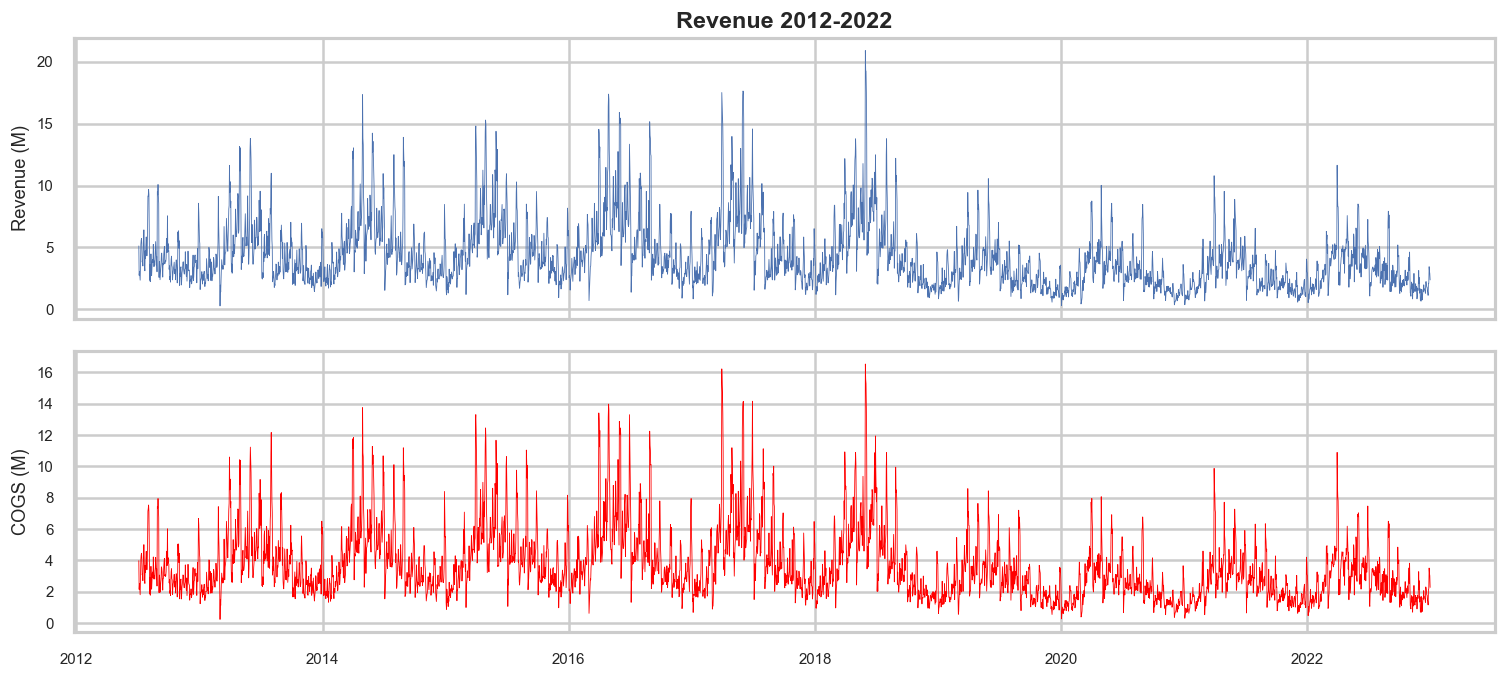

In [96]:
fig, axes = plt.subplots(2, 1, figsize=(13, 6), sharex=True)
axes[0].plot(sales.Date, sales.Revenue/1e6, lw=0.5)
axes[0].set_ylabel('Revenue (M)'); axes[0].set_title('Revenue 2012-2022')
axes[1].plot(sales.Date, sales.COGS/1e6, lw=0.5, color='red')
axes[1].set_ylabel('COGS (M)')
plt.tight_layout(); plt.show()

### 2.2 Monthly seasonality

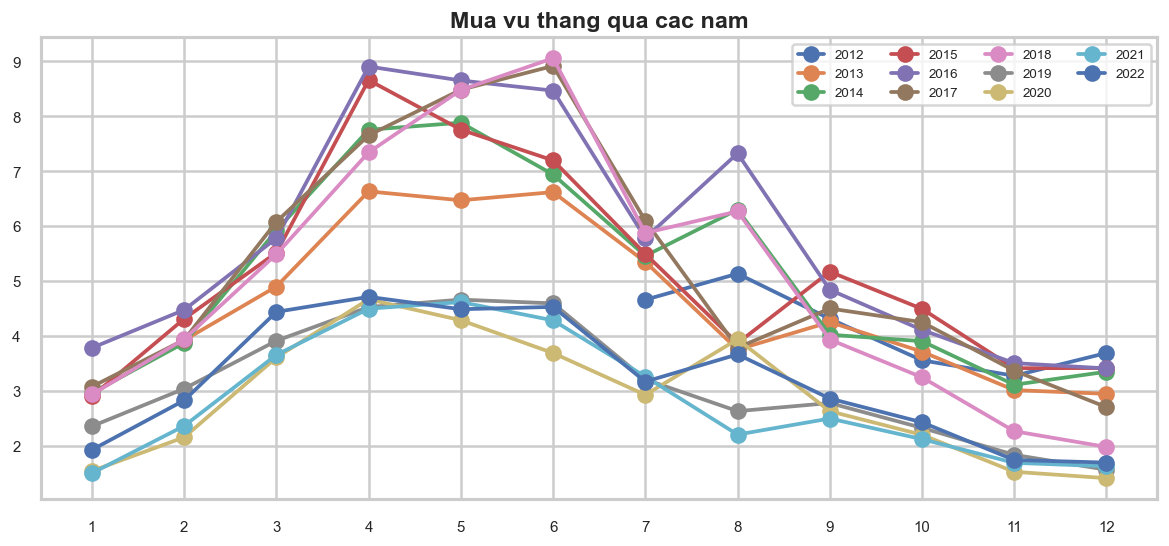

In [97]:
monthly = sales.groupby(['Y','M']).Revenue.mean().reset_index()
fig, ax = plt.subplots(figsize=(12, 5))
for y in sorted(sales.Y.unique()):
    d = monthly[monthly.Y == y]
    ax.plot(d.M, d.Revenue/1e6, marker='o', label=str(y))
ax.set_xticks(range(1,13)); ax.legend(ncol=4, fontsize=8)
ax.set_title('Mua vu thang qua cac nam')
plt.show()

### 2.3 Quarterly margin (Q3 zigzag chẵn/lẻ)

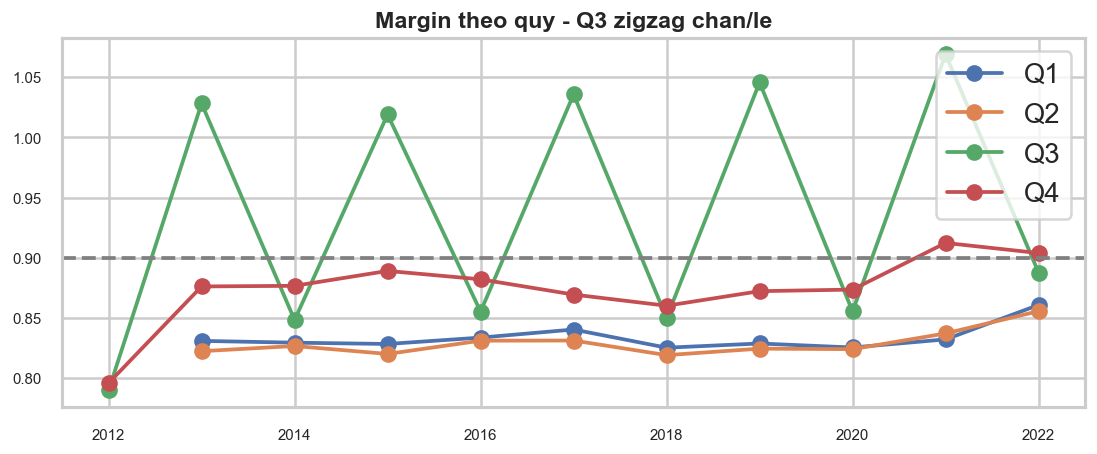

In [98]:
q_marg = sales.groupby(['Y','Q']).apply(
    lambda d: d.COGS.sum()/d.Revenue.sum(), include_groups=False).reset_index()
q_marg.columns = ['Y','Q','margin']

fig, ax = plt.subplots(figsize=(11, 4))
for q in [1,2,3,4]:
    d = q_marg[q_marg.Q == q]
    ax.plot(d.Y, d.margin, marker='o', label=f'Q{q}')
ax.axhline(0.9, color='gray', ls='--')
ax.set_title('Margin theo quy - Q3 zigzag chan/le')
ax.legend(); plt.show()

## 3. Feature Engineering — calendar-only


In [99]:
TET_DATES = {
    2013:'2013-02-10', 2014:'2014-01-31', 2015:'2015-02-19',
    2016:'2016-02-08', 2017:'2017-01-28', 2018:'2018-02-16',
    2019:'2019-02-05', 2020:'2020-01-25', 2021:'2021-02-12',
    2022:'2022-02-01', 2023:'2023-01-22', 2024:'2024-02-10',
}

VN_FIXED_HOLIDAYS = [
    (1,1,'new_year'), (3,8,'womens_day'), (4,30,'reunification'),
    (5,1,'labor_day'), (9,2,'national_day'), (10,20,'vn_womens_day'),
    (11,11,'dd_1111'), (12,12,'dd_1212'),
    (12,24,'christmas_eve'), (12,25,'christmas'),
]

PROMO_RULES = {
    'all_years': [
        ((3, 18), (4, 17)),
        ((6, 23), (7, 22)),
        ((8, 30), (10, 2)),
    ],
    'odd_years': [
        ((1, 31), (3, 1)),
        ((7, 30), (9, 2)),
        ((11, 18), (1, 2)),
    ],
    'even_years': [
        ((11, 19), (1, 2)),
    ],
}


def _promo_windows_for_year(year):
    windows = []
    for start_md, end_md in PROMO_RULES['all_years']:
        windows.append((
            pd.Timestamp(year=year, month=start_md[0], day=start_md[1]),
            pd.Timestamp(year=year, month=end_md[0], day=end_md[1]),
        ))

    parity_key = 'odd_years' if year % 2 == 1 else 'even_years'
    for start_md, end_md in PROMO_RULES[parity_key]:
        end_year = year + 1 if end_md[0] < start_md[0] else year
        windows.append((
            pd.Timestamp(year=year, month=start_md[0], day=start_md[1]),
            pd.Timestamp(year=end_year, month=end_md[0], day=end_md[1]),
        ))
    return windows

# Vietnam labor law lets employers and employees agree a regular monthly/semi-monthly cycle.
# In practice, payroll is commonly paid near month-end or within the first days of the next month.
VN_PAYDAY_START = 25
VN_PAYDAY_END = 10




In [100]:
def build_features(dates):
    df = pd.DataFrame({'Date': dates})
    d = df['Date']

    # Calendar
    df['year']    = d.dt.year
    df['month']   = d.dt.month
    df['day']     = d.dt.day
    df['dow']     = d.dt.dayofweek
    df['doy']     = d.dt.dayofyear
    df['quarter'] = d.dt.quarter
    df['is_weekend']    = (df['dow']>=5).astype(int)
    df['days_to_eom']   = d.dt.days_in_month - df['day']
    df['days_from_som'] = df['day'] - 1
    df['dim']           = d.dt.days_in_month

    # Edge of month
    for k in [1,2,3]:
        df[f'is_last{k}']  = (df['days_to_eom']  <= k-1).astype(int)
        df[f'is_first{k}'] = (df['days_from_som'] <= k-1).astype(int)

    # Trend + regime
    df['t_days']  = (d - pd.Timestamp('2020-01-01')).dt.days
    df['t_years'] = df['t_days']/365.25
    df['regime_pre2019']  = (df['year']<=2018).astype(int)
    df['regime_2019']     = (df['year']==2019).astype(int)
    df['regime_post2019'] = (df['year']>=2020).astype(int)

    # Fourier
    TAU = 2*np.pi
    for k in (1,2,3,4,5):
        df[f'sin_y{k}'] = np.sin(TAU*k*df['doy']/365.25)
        df[f'cos_y{k}'] = np.cos(TAU*k*df['doy']/365.25)
    for k in (1,2):
        df[f'sin_w{k}'] = np.sin(TAU*k*df['dow']/7.0)
        df[f'cos_w{k}'] = np.cos(TAU*k*df['dow']/7.0)
    for k in (1,2):
        df[f'sin_m{k}'] = np.sin(TAU*k*(df['day']-1)/df['dim'])
        df[f'cos_m{k}'] = np.cos(TAU*k*(df['day']-1)/df['dim'])

    # Holidays
    for (m, dd_, name) in VN_FIXED_HOLIDAYS:
        df[f'hol_{name}'] = ((df['month']==m) & (df['day']==dd_)).astype(int)

    # Tet distance
    tet_lut = {y: pd.Timestamp(v) for y,v in TET_DATES.items()}
    def nearest_tet_diff(dd):
        cands = [tet_lut.get(dd.year), tet_lut.get(dd.year-1), tet_lut.get(dd.year+1)]
        cands = [c for c in cands if c is not None]
        valid = [(dd-c).days for c in cands if abs((dd-c).days)<=45]
        return min(valid) if valid else 999
    diffs = np.array([nearest_tet_diff(dd) for dd in d])
    df['tet_days_diff'] = diffs
    df['tet_in_7']      = (np.abs(diffs)<=7).astype(int)
    df['tet_in_14']     = (np.abs(diffs)<=14).astype(int)
    df['tet_before_7']  = ((diffs>=-7) & (diffs<0)).astype(int)
    df['tet_after_7']   = ((diffs>0) & (diffs<=7)).astype(int)
    df['tet_on']        = (diffs==0).astype(int)

    # Black Friday
    def is_bf(dd):
        if dd.month != 11: return 0
        last = pd.Timestamp(year=dd.year, month=11, day=30)
        last_fri = last - pd.Timedelta(days=(last.dayofweek - 4) % 7)
        return int(dd == last_fri)
    df['hol_black_friday'] = [is_bf(dd) for dd in d]

    # Generic promo flag from fixed business rules inferred beforehand
    has_promo = np.zeros(len(df), dtype=int)
    yrs = sorted(set(df['year'].tolist()))
    for y in range(min(yrs)-1, max(yrs)+2):
        for start, end in _promo_windows_for_year(y):
            mask = (d >= start) & (d <= end)
            has_promo[mask] = 1
    df['has_promo'] = has_promo

    # Common Vietnam payroll window: near month-end or first days of next month
    df['is_salary_window_vn'] = ((df['day'] >= VN_PAYDAY_START) | (df['day'] <= VN_PAYDAY_END)).astype(int)

    df['is_odd_year'] = (df['year'] % 2).astype(int)
    return df

print('Test:', build_features(pd.date_range('2023-01-01','2023-01-05')).shape)



Test: (5, 82)


## 4. Chuẩn bị data train + test

In [101]:
feat = build_features(sales['Date'])
feat['Revenue'] = sales['Revenue'].values
feat['COGS']    = sales['COGS'].values

test_dates = pd.date_range('2023-01-01', '2024-07-01', freq='D')
test_df = build_features(test_dates)

NON_FEATURES = {'Date','Revenue','COGS'}
cols = [c for c in feat.columns if c not in NON_FEATURES]

X_tr = feat[cols].values.astype(float)
X_te = test_df[cols].values.astype(float)
y_rev = np.log(feat['Revenue'].values)
y_cog = np.log(feat['COGS'].values)
years = feat['Date'].dt.year.values

print(f'Training: {X_tr.shape}, Test: {X_te.shape}, Features: {len(cols)}')

Training: (3833, 81), Test: (548, 81), Features: 81


## 5. Sample weight (high_era)

Ưu tiên 2014-2018 vì đây là vùng có seasonality rõ nhất.

In [102]:
w_full = np.full(len(years), 0.01)
w_full[(years>=2014) & (years<=2018)] = 1.0
print(f'Days with w=1.0: {(w_full==1.0).sum()}, w=0.01: {(w_full==0.01).sum()}')

Days with w=1.0: 1826, w=0.01: 2007


## 6. M1 — Ridge Regression

In [103]:
def train_ridge(X_train, y_train, alpha=3.0):
    mu = X_train.mean(axis=0)
    sigma = X_train.std(axis=0).replace(0, 1)
    Xs = (X_train - mu) / sigma
    m = Ridge(alpha=alpha, random_state=42)
    m.fit(Xs, y_train)
    return m, (mu, sigma)

def predict_ridge(model, X_test, stats):
    mu, sigma = stats
    return model.predict((X_test - mu) / sigma)

ridge_rev, st_r = train_ridge(pd.DataFrame(X_tr, columns=cols), y_rev)
ridge_cog, st_c = train_ridge(pd.DataFrame(X_tr, columns=cols), y_cog)

p_rd_rev = np.exp(predict_ridge(ridge_rev, pd.DataFrame(X_te, columns=cols), st_r))
p_rd_cog = np.exp(predict_ridge(ridge_cog, pd.DataFrame(X_te, columns=cols), st_c))

print(f'Ridge Revenue: {p_rd_rev.mean():,.0f}')
print(f'Ridge COGS:    {p_rd_cog.mean():,.0f}')

Ridge Revenue: 3,030,994
Ridge COGS:    2,721,462


## 7. M2 — LightGBM (high_era)

Two-stage: early stopping → retrain với best_iteration.

In [104]:
LGB_PARAMS = dict(
    objective='regression', metric='mae',
    learning_rate=0.03, num_leaves=63,
    min_data_in_leaf=30,
    feature_fraction=0.85, bagging_fraction=0.85, bagging_freq=5,
    lambda_l2=1.0, seed=42, verbosity=-1,
)

def train_lgb(X, y, w, num_boost_es=5000, early_stop=300):
    intern = pd.Timestamp('2022-07-04')
    fit_idx = (feat['Date'] <= intern).values
    ins_idx = (feat['Date'] >  intern).values

    bk = lgb.train(
        LGB_PARAMS,
        lgb.Dataset(X[fit_idx], y[fit_idx], weight=w[fit_idx]),
        num_boost_round=num_boost_es,
        valid_sets=[lgb.Dataset(X[ins_idx], y[ins_idx])],
        callbacks=[lgb.early_stopping(early_stop, verbose=False),
                   lgb.log_evaluation(0)])

    bf = lgb.train(LGB_PARAMS,
                   lgb.Dataset(X, y, weight=w),
                   num_boost_round=bk.best_iteration)
    return bf, bk.best_iteration

In [105]:
print('Train LGB Revenue...')
bf_rev, it_rev = train_lgb(X_tr, y_rev, w_full)
print(f'  best_iter={it_rev}')

print('Train LGB COGS...')
bf_cog, it_cog = train_lgb(X_tr, y_cog, w_full)
print(f'  best_iter={it_cog}')

p_lgb_rev = np.exp(bf_rev.predict(X_te))
p_lgb_cog = np.exp(bf_cog.predict(X_te))

print(f'LGB Revenue: {p_lgb_rev.mean():,.0f}')
print(f'LGB COGS:    {p_lgb_cog.mean():,.0f}')

Train LGB Revenue...
  best_iter=327
Train LGB COGS...
  best_iter=513
LGB Revenue: 3,321,046
LGB COGS:    2,908,132


## 8. M3 — Prophet (post-regime only)

In [106]:
def build_promo_regressors(dates):
    full = build_features(dates)
    return full[['Date', 'has_promo']].rename(columns={'Date':'ds'})

def fit_prophet(train_df, post_regime_only=True):
    if post_regime_only:
        train_df = train_df[train_df['ds'] >= '2020-01-01']
    m = Prophet(yearly_seasonality=True, weekly_seasonality=True,
                daily_seasonality=False,
                seasonality_mode='multiplicative',
                changepoint_prior_scale=0.05)
    for col in [c for c in train_df.columns if c.startswith('promo_')]:
        m.add_regressor(col)
    m.fit(train_df)
    return m

In [107]:
print('Train Prophet Revenue...')
tdf_r = pd.DataFrame({'ds': sales['Date'], 'y': np.log(sales['Revenue'])}) \
          .merge(build_promo_regressors(sales['Date']), on='ds')
mp_r = fit_prophet(tdf_r)

print('Train Prophet COGS...')
tdf_c = pd.DataFrame({'ds': sales['Date'], 'y': np.log(sales['COGS'])}) \
          .merge(build_promo_regressors(sales['Date']), on='ds')
mp_c = fit_prophet(tdf_c)

vdf = pd.DataFrame({'ds': test_df['Date']}) \
        .merge(build_promo_regressors(test_df['Date']), on='ds')
p_pr_rev = np.exp(mp_r.predict(vdf)['yhat'].values)
p_pr_cog = np.exp(mp_c.predict(vdf)['yhat'].values)

print(f'Prophet Revenue: {p_pr_rev.mean():,.0f}')
print(f'Prophet COGS:    {p_pr_cog.mean():,.0f}')

Train Prophet Revenue...
Train Prophet COGS...
Prophet Revenue: 3,874,351
Prophet COGS:    3,218,076


## 9. Q-Specialists — 8 LightGBM (4 quý × 2 target)

Mỗi specialist boost 2× weight cho quý trọng điểm. Khi predict, ghép theo quý của test date.

In [108]:
def train_q_specialist(X, y, w_base, target_q, q_boost=2.0):
    Q_train = feat['Date'].dt.quarter.values
    w = w_base.copy()
    w[Q_train == target_q] *= q_boost
    bf, _ = train_lgb(X, y, w, num_boost_es=3000, early_stop=200)
    return bf

spec_rev = {}
spec_cog = {}
for q in [1, 2, 3, 4]:
    print(f'Spec_Q{q} Revenue...')
    bf = train_q_specialist(X_tr, y_rev, w_full, q)
    spec_rev[q] = np.exp(bf.predict(X_te))

    print(f'Spec_Q{q} COGS...')
    bf = train_q_specialist(X_tr, y_cog, w_full, q)
    spec_cog[q] = np.exp(bf.predict(X_te))

print('Done 8 specialists.')

Spec_Q1 Revenue...
Spec_Q1 COGS...
Spec_Q2 Revenue...
Spec_Q2 COGS...
Spec_Q3 Revenue...
Spec_Q3 COGS...
Spec_Q4 Revenue...
Spec_Q4 COGS...
Done 8 specialists.


In [109]:
# Ghep theo quy cua test date
Q_test = test_df['Date'].dt.quarter.values
lgb_spec_rev = np.zeros(len(test_dates))
lgb_spec_cog = np.zeros(len(test_dates))
for q in [1,2,3,4]:
    mask = Q_test == q
    lgb_spec_rev[mask] = spec_rev[q][mask]
    lgb_spec_cog[mask] = spec_cog[q][mask]

## 10. Ensemble 3-tầng + Calibration

In [110]:
ALPHA = 0.60   # specialist vs base LGB
CR    = 1.26   # calibration Revenue
CC    = 1.32   # calibration COGS

# Tang 1: LGB blend
lgb_blend_rev = ALPHA * lgb_spec_rev + (1 - ALPHA) * p_lgb_rev
lgb_blend_cog = ALPHA * lgb_spec_cog + (1 - ALPHA) * p_lgb_cog

# Tang 2: 3-way blend
raw_rev = 0.10 * p_pr_rev + 0.10 * p_rd_rev + 0.80 * lgb_blend_rev
raw_cog = 0.10 * p_pr_cog + 0.10 * p_rd_cog + 0.80 * lgb_blend_cog

# Tang 3: calibration
final_rev = CR * raw_rev
final_cog = CC * raw_cog

print(f'Final Revenue: {final_rev.mean():,.0f}')
print(f'Final COGS:    {final_cog.mean():,.0f}')

Final Revenue: 4,181,704
Final COGS:    3,846,621


## 11. Save submission

In [111]:
sub = pd.DataFrame({
    'Date':    test_df['Date'].dt.strftime('%Y-%m-%d').values,
    'Revenue': final_rev,
    'COGS':    final_cog,
})

out_path = 'submission.csv'
sub.to_csv(out_path, index=False)
print(f'Saved: {out_path}')
sub.head()

Saved: submission.csv


,Date,Revenue,COGS
0,2023-01-01,2.426066e+06,2.512354e+06
1,2023-01-02,1.763015e+06,1.728356e+06
2,2023-01-03,1.631711e+06,1.523017e+06
3,2023-01-04,1.207054e+06,1.112135e+06
4,2023-01-05,1.383486e+06,1.257235e+06


## 12. (Bonus) — Mean-preserving margin fix

Hậu xử lý kéo Q3 margin về historical, giữ nguyên cog_mean toàn cục. Cải thiện thêm ~1K LB.

In [ ]:
target_cog_mean = sub.COGS.mean()

recent_margin = {q: sales[(sales.Q==q) & (sales.Y>=2020)].COGS.sum() /
                    sales[(sales.Q==q) & (sales.Y>=2020)].Revenue.sum()
                 for q in [1,2,3,4]}

sub_v57 = sub.copy()
sub_v57['Date_dt'] = pd.to_datetime(sub_v57['Date'])
sub_v57['Q'] = sub_v57['Date_dt'].dt.quarter

BETA = 0.30
for q in [1,2,3,4]:
    mask = sub_v57.Q == q
    historical_cog = sub_v57.loc[mask, 'Revenue'] * recent_margin[q]
    sub_v57.loc[mask, 'COGS'] = (1-BETA)*sub_v57.loc[mask, 'COGS'] + BETA*historical_cog

scale = target_cog_mean / sub_v57.COGS.mean()
sub_v57['COGS'] = sub_v57['COGS'] * scale

out_v57 = 'submission_v57_mp_blend30.csv'
sub_v57[['Date','Revenue','COGS']].to_csv(out_v57, index=False)
print(f'Saved v57: {out_v57}')

NameError: name 'OUT_DIR' is not defined

## 13. Model Testing ? fast GPU benchmark

Section n?y benchmark nhanh c?c model m?i theo holdout c? ??nh, ?u ti?n GPU n?u m?y c? `CUDA`, v? gi?m ?? ph?c t?p ?? ch?y th?c t? h?n.


In [ ]:
import importlib
import subprocess
import sys
import warnings
import logging

REQUIRED_PACKAGES = {
    'catboost': 'catboost',
}

def ensure_package(module_name, pip_name):
    try:
        importlib.import_module(module_name)
        print(f"[ok] {module_name}")
    except ModuleNotFoundError:
        print(f"[install] {pip_name}")
        subprocess.check_call([sys.executable, "-m", "pip", "install", pip_name, "--quiet"])

for module_name, pip_name in REQUIRED_PACKAGES.items():
    ensure_package(module_name, pip_name)

warnings.filterwarnings("ignore")
logging.getLogger("pytorch_lightning").setLevel(logging.ERROR)
logging.getLogger("lightning").setLevel(logging.ERROR)

import torch
from IPython.display import display
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from catboost import CatBoostRegressor

MODEL_TEST_TARGETS = ["Revenue", "COGS"]
INCLUDE_PROPHET_IN_BENCHMARK = False  # Prophet chay kha cham
RUN_DEEP_MODELS = False              # de False de uu tien benchmark nhanh cac model don gian
RUN_NBEATSX = False                  # chi co tac dung khi RUN_DEEP_MODELS=True

if RUN_DEEP_MODELS:
    ensure_package('neuralforecast', 'neuralforecast')
    from neuralforecast import NeuralForecast
    from neuralforecast.models import NHITS, TiDE, NBEATSx
    from neuralforecast.losses.pytorch import MSE

HOLDOUT_START = pd.Timestamp("2022-07-05")
HOLDOUT_DAYS = int((feat["Date"] >= HOLDOUT_START).sum())
NF_INPUT_SIZE = 90
NF_MAX_STEPS = 12
NF_BATCH_SIZE = 32

USE_GPU = torch.cuda.is_available()
ACCELERATOR = "gpu" if USE_GPU else "cpu"
DEVICES = 1
CATBOOST_TASK_TYPE = "GPU" if USE_GPU else "CPU"

print("CUDA available:", USE_GPU)
if USE_GPU:
    print("GPU:", torch.cuda.get_device_name(0))
print("CatBoost task_type:", CATBOOST_TASK_TYPE)
print("Targets:", MODEL_TEST_TARGETS)
print("Holdout:", HOLDOUT_START.date(), "->", feat["Date"].max().date(), f"({HOLDOUT_DAYS} days)")
print("Deep config:", {"enabled": RUN_DEEP_MODELS, "input_size": NF_INPUT_SIZE, "max_steps": NF_MAX_STEPS, "batch_size": NF_BATCH_SIZE})


In [ ]:
holdout_mask = (feat["Date"] >= HOLDOUT_START).values
train_mask = ~holdout_mask
exo_cols = cols.copy()

def metric_row(y_true, y_pred, model_name, target_name):
    y_pred = np.clip(np.asarray(y_pred, dtype=float), 1.0, None)
    return {
        "model": model_name,
        "target": target_name,
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": mean_squared_error(y_true, y_pred) ** 0.5,
        "R2": r2_score(y_true, y_pred),
    }

def fit_predict_ridge_holdout(target_col, alpha=3.0):
    X_train = pd.DataFrame(feat.loc[train_mask, exo_cols].values, columns=exo_cols)
    X_hold = pd.DataFrame(feat.loc[holdout_mask, exo_cols].values, columns=exo_cols)
    y_train = np.log(feat.loc[train_mask, target_col].values)
    model, stats = train_ridge(X_train, y_train, alpha=alpha)
    return np.exp(predict_ridge(model, X_hold, stats))

def fit_predict_lgb_holdout(target_col):
    y_all = np.log(feat[target_col].values)
    X_all = feat[exo_cols].values.astype(float)
    tune_start = HOLDOUT_START - pd.Timedelta(days=HOLDOUT_DAYS)
    fit_mask = (feat["Date"] < tune_start).values
    val_mask = ((feat["Date"] >= tune_start) & (feat["Date"] < HOLDOUT_START)).values
    test_mask = holdout_mask

    model = lgb.train(
        LGB_PARAMS,
        lgb.Dataset(X_all[fit_mask], y_all[fit_mask], weight=w_full[fit_mask]),
        num_boost_round=1500,
        valid_sets=[lgb.Dataset(X_all[val_mask], y_all[val_mask])],
        callbacks=[lgb.early_stopping(80, verbose=False), lgb.log_evaluation(0)],
    )
    return np.exp(model.predict(X_all[test_mask], num_iteration=model.best_iteration))

def fit_predict_lgb_variant_holdout(target_col, model_name, objective='regression', metric='rmse', extra_params=None):
    y_all = np.log(feat[target_col].values)
    X_all = feat[exo_cols].values.astype(float)
    tune_start = HOLDOUT_START - pd.Timedelta(days=HOLDOUT_DAYS)
    fit_mask = (feat["Date"] < tune_start).values
    val_mask = ((feat["Date"] >= tune_start) & (feat["Date"] < HOLDOUT_START)).values
    test_mask = holdout_mask

    params = dict(LGB_PARAMS)
    params.update({'objective': objective, 'metric': metric})
    if extra_params:
        params.update(extra_params)

    model = lgb.train(
        params,
        lgb.Dataset(X_all[fit_mask], y_all[fit_mask], weight=w_full[fit_mask]),
        num_boost_round=1500,
        valid_sets=[lgb.Dataset(X_all[val_mask], y_all[val_mask])],
        callbacks=[lgb.early_stopping(80, verbose=False), lgb.log_evaluation(0)],
    )
    return np.exp(model.predict(X_all[test_mask], num_iteration=model.best_iteration))

def fit_predict_catboost_holdout(target_col):
    y_all = np.log(feat[target_col].values)
    X_all = feat[exo_cols].values.astype(float)
    tune_start = HOLDOUT_START - pd.Timedelta(days=HOLDOUT_DAYS)
    fit_mask = (feat["Date"] < tune_start).values
    val_mask = ((feat["Date"] >= tune_start) & (feat["Date"] < HOLDOUT_START)).values
    test_mask = holdout_mask

    model = CatBoostRegressor(
        loss_function='RMSE',
        eval_metric='RMSE',
        iterations=1200,
        learning_rate=0.03,
        depth=6,
        l2_leaf_reg=3.0,
        random_seed=42,
        od_type='Iter',
        od_wait=80,
        verbose=False,
        allow_writing_files=False,
        task_type=CATBOOST_TASK_TYPE,
    )
    model.fit(
        X_all[fit_mask], y_all[fit_mask],
        sample_weight=w_full[fit_mask],
        eval_set=(X_all[val_mask], y_all[val_mask]),
        use_best_model=True,
    )
    return np.exp(model.predict(X_all[test_mask]))

def fit_predict_prophet_holdout(target_col):
    target_log = np.log(feat[target_col].values)
    full_df = pd.DataFrame({"ds": feat["Date"], "y": target_log}).merge(
        build_promo_regressors(feat["Date"]), on="ds"
    )
    train_df = full_df[full_df["ds"] < HOLDOUT_START].copy()
    valid_df = full_df[full_df["ds"] >= HOLDOUT_START].copy()
    model = fit_prophet(train_df, post_regime_only=True)
    return np.exp(model.predict(valid_df)["yhat"].values)

def make_nf_frames(target_col):
    full = feat[["Date", target_col] + exo_cols].copy()
    full = full.rename(columns={"Date": "ds", target_col: "y"})
    full["unique_id"] = target_col.lower()
    full = full[["unique_id", "ds", "y"] + exo_cols]
    train_df = full[full["ds"] < HOLDOUT_START].copy()
    holdout_df = full[full["ds"] >= HOLDOUT_START].copy()
    futr_df = holdout_df[["unique_id", "ds"] + exo_cols].copy()
    return train_df, holdout_df, futr_df

def build_nf_models(h):
    common = dict(
        h=h,
        input_size=NF_INPUT_SIZE,
        futr_exog_list=exo_cols,
        loss=MSE(),
        max_steps=NF_MAX_STEPS,
        val_check_steps=max(4, NF_MAX_STEPS // 2),
        early_stop_patience_steps=2,
        batch_size=NF_BATCH_SIZE,
        windows_batch_size=128,
        inference_windows_batch_size=128,
        scaler_type="standard",
        accelerator=ACCELERATOR,
        devices=DEVICES,
        logger=False,
        enable_checkpointing=False,
        enable_progress_bar=False,
        enable_model_summary=False,
    )
    models = [
        NHITS(
            alias="NHITS",
            mlp_units=3 * [[64, 64]],
            n_pool_kernel_size=[4, 2, 1],
            n_freq_downsample=[8, 4, 1],
            **common,
        ),
        TiDE(
            alias="TiDE",
            hidden_size=64,
            decoder_output_dim=8,
            temporal_decoder_dim=32,
            num_encoder_layers=1,
            num_decoder_layers=1,
            **common,
        ),
    ]
    if RUN_NBEATSX:
        models.append(
            NBEATSx(
                alias="NBEATSx",
                mlp_units=3 * [[64, 64]],
                **common,
            )
        )
    return models

def fit_predict_nf_holdout(target_col):
    train_df, holdout_df, futr_df = make_nf_frames(target_col)
    nf = NeuralForecast(models=build_nf_models(len(holdout_df)), freq="D")
    nf.fit(df=train_df, val_size=min(len(holdout_df), 180), verbose=False)
    pred_df = nf.predict(futr_df=futr_df, verbose=False)
    out = {}
    for model_name in [m.alias for m in nf.models]:
        out[model_name] = pred_df[model_name].values
    return holdout_df["y"].values, out

model_rows = []
for target_col in MODEL_TEST_TARGETS:
    y_true = feat.loc[holdout_mask, target_col].values
    print(f"\n===== TARGET: {target_col} =====")

    pred_ridge = fit_predict_ridge_holdout(target_col)
    model_rows.append(metric_row(y_true, pred_ridge, "Ridge", target_col))

    pred_lgb = fit_predict_lgb_holdout(target_col)
    model_rows.append(metric_row(y_true, pred_lgb, "LightGBM", target_col))

    pred_lgb_rmse = fit_predict_lgb_variant_holdout(target_col, "LightGBM-RMSE", objective='regression', metric='rmse')
    model_rows.append(metric_row(y_true, pred_lgb_rmse, "LightGBM-RMSE", target_col))

    pred_lgb_huber = fit_predict_lgb_variant_holdout(target_col, "LightGBM-Huber", objective='huber', metric='huber', extra_params={'alpha': 0.9})
    model_rows.append(metric_row(y_true, pred_lgb_huber, "LightGBM-Huber", target_col))

    pred_cat = fit_predict_catboost_holdout(target_col)
    model_rows.append(metric_row(y_true, pred_cat, "CatBoost", target_col))

    if INCLUDE_PROPHET_IN_BENCHMARK:
        pred_prophet = fit_predict_prophet_holdout(target_col)
        model_rows.append(metric_row(y_true, pred_prophet, "Prophet", target_col))

    if RUN_DEEP_MODELS:
        _, nf_preds = fit_predict_nf_holdout(target_col)
        for model_name, pred in nf_preds.items():
            model_rows.append(metric_row(y_true, pred, model_name, target_col))

model_test_results = pd.DataFrame(model_rows)
model_test_results["MAE_rank"] = model_test_results.groupby("target")["MAE"].rank(method="dense")
model_test_results["RMSE_rank"] = model_test_results.groupby("target")["RMSE"].rank(method="dense")
model_test_results["R2_rank"] = model_test_results.groupby("target")["R2"].rank(method="dense", ascending=False)
model_test_results["combo_rank"] = model_test_results[["MAE_rank", "RMSE_rank", "R2_rank"]].mean(axis=1)

display(model_test_results.sort_values(["target", "combo_rank", "RMSE"]).reset_index(drop=True))
display(
    model_test_results.groupby("model")[["MAE", "RMSE", "R2", "combo_rank"]]
    .mean()
    .sort_values(["combo_rank", "RMSE"])
    .round(4)
)


## 14. Lag Feature Experiment ? recursive, no leakage

Section n?y t?o th?m `lag + rolling` ch? t? `sales.csv`, sau ?? benchmark l?i c?c model ??n gi?n b?ng c?ch d? b?o tu?n t? tr?n holdout ?? tr?nh leakage.


In [ ]:

LAG_EXPERIMENT_TARGETS = ["Revenue", "COGS"]
LAG_LIST = [1, 7, 14, 28, 56, 84, 364]
ROLL_WINDOWS = [7, 14, 28, 56]


def build_lag_training_frame(target_col, lags=LAG_LIST, roll_windows=ROLL_WINDOWS):
    base = build_features(sales['Date']).copy()
    y_log = np.log(sales[target_col].astype(float))
    shifted = y_log.shift(1)

    base['Date'] = sales['Date'].values
    base['y'] = y_log.values
    base['weight'] = w_full.copy()

    for lag in lags:
        base[f'lag_{lag}'] = y_log.shift(lag)

    for w in roll_windows:
        base[f'roll_mean_{w}'] = shifted.rolling(w).mean()
        base[f'roll_std_{w}'] = shifted.rolling(w).std()
        base[f'ewm_{w}'] = shifted.ewm(span=w, adjust=False).mean()

    base['lag_1_minus_7'] = base['lag_1'] - base['lag_7']
    base['lag_7_minus_28'] = base['lag_7'] - base['lag_28']

    feature_cols = [c for c in base.columns if c not in {'Date', 'y', 'weight'}]
    valid_mask = base[feature_cols].notna().all(axis=1)
    out = base.loc[valid_mask].reset_index(drop=True)
    return out, feature_cols


def _ewm_last(values, span):
    s = pd.Series(values)
    return s.ewm(span=span, adjust=False).mean().iloc[-1]


def make_recursive_feature_frame(target_col, feature_cols, holdout_dates, lags=LAG_LIST, roll_windows=ROLL_WINDOWS):
    history_log = list(np.log(sales.loc[sales['Date'] < HOLDOUT_START, target_col].astype(float).values))
    cal = build_features(holdout_dates).reset_index(drop=True)
    rows = []

    for i, dt in enumerate(holdout_dates):
        row = cal.iloc[i].to_dict()
        arr = np.asarray(history_log, dtype=float)

        for lag in lags:
            row[f'lag_{lag}'] = arr[-lag]

        for w in roll_windows:
            window = arr[-w:]
            row[f'roll_mean_{w}'] = float(window.mean())
            row[f'roll_std_{w}'] = float(window.std(ddof=1)) if len(window) > 1 else 0.0
            row[f'ewm_{w}'] = float(_ewm_last(window, w))

        row['lag_1_minus_7'] = row['lag_1'] - row['lag_7']
        row['lag_7_minus_28'] = row['lag_7'] - row['lag_28']
        rows.append(row)

    return pd.DataFrame(rows)[feature_cols]


def recursive_forecast_with_model(model, feature_cols, target_col, predict_fn=None):
    holdout_dates = feat.loc[holdout_mask, 'Date'].reset_index(drop=True)
    history_log = list(np.log(sales.loc[sales['Date'] < HOLDOUT_START, target_col].astype(float).values))
    cal = build_features(holdout_dates).reset_index(drop=True)
    preds_log = []

    for i, dt in enumerate(holdout_dates):
        row = cal.iloc[i].to_dict()
        arr = np.asarray(history_log, dtype=float)

        for lag in LAG_LIST:
            row[f'lag_{lag}'] = arr[-lag]

        for w in ROLL_WINDOWS:
            window = arr[-w:]
            row[f'roll_mean_{w}'] = float(window.mean())
            row[f'roll_std_{w}'] = float(window.std(ddof=1)) if len(window) > 1 else 0.0
            row[f'ewm_{w}'] = float(_ewm_last(window, w))

        row['lag_1_minus_7'] = row['lag_1'] - row['lag_7']
        row['lag_7_minus_28'] = row['lag_7'] - row['lag_28']

        X_row = pd.DataFrame([row])[feature_cols]
        if predict_fn is None:
            pred_log = float(model.predict(X_row.values.astype(float))[0])
        else:
            pred_log = float(predict_fn(model, X_row))
        preds_log.append(pred_log)
        history_log.append(pred_log)

    return np.exp(np.asarray(preds_log))


def fit_predict_ridge_lag_holdout(target_col):
    lag_df, feature_cols = build_lag_training_frame(target_col)
    train_df = lag_df[lag_df['Date'] < HOLDOUT_START].copy()
    model, stats = train_ridge(train_df[feature_cols], train_df['y'])

    def _pred_fn(m, X_row):
        return predict_ridge(m, X_row, stats)[0]

    pred = recursive_forecast_with_model(model, feature_cols, target_col, predict_fn=_pred_fn)
    return pred


def fit_predict_lgb_lag_holdout(target_col, params_override=None):
    lag_df, feature_cols = build_lag_training_frame(target_col)
    tune_start = HOLDOUT_START - pd.Timedelta(days=HOLDOUT_DAYS)
    fit_df = lag_df[lag_df['Date'] < tune_start].copy()
    val_df = lag_df[(lag_df['Date'] >= tune_start) & (lag_df['Date'] < HOLDOUT_START)].copy()

    params = dict(LGB_PARAMS)
    if params_override:
        params.update(params_override)

    model = lgb.train(
        params,
        lgb.Dataset(fit_df[feature_cols].values.astype(float), fit_df['y'].values, weight=fit_df['weight'].values),
        num_boost_round=1500,
        valid_sets=[lgb.Dataset(val_df[feature_cols].values.astype(float), val_df['y'].values)],
        callbacks=[lgb.early_stopping(80, verbose=False), lgb.log_evaluation(0)],
    )

    def _pred_fn(m, X_row):
        return m.predict(X_row.values.astype(float), num_iteration=m.best_iteration)[0]

    pred = recursive_forecast_with_model(model, feature_cols, target_col, predict_fn=_pred_fn)
    return pred


def fit_predict_catboost_lag_holdout(target_col):
    lag_df, feature_cols = build_lag_training_frame(target_col)
    tune_start = HOLDOUT_START - pd.Timedelta(days=HOLDOUT_DAYS)
    fit_df = lag_df[lag_df['Date'] < tune_start].copy()
    val_df = lag_df[(lag_df['Date'] >= tune_start) & (lag_df['Date'] < HOLDOUT_START)].copy()

    model_kwargs = dict(
        loss_function='RMSE',
        eval_metric='RMSE',
        iterations=1200,
        learning_rate=0.03,
        depth=6,
        l2_leaf_reg=3.0,
        random_seed=42,
        od_type='Iter',
        od_wait=80,
        verbose=False,
        allow_writing_files=False,
    )

    try:
        model = CatBoostRegressor(task_type=CATBOOST_TASK_TYPE, **model_kwargs)
        model.fit(
            fit_df[feature_cols], fit_df['y'],
            sample_weight=fit_df['weight'],
            eval_set=(val_df[feature_cols], val_df['y']),
            use_best_model=True,
        )
    except Exception:
        model = CatBoostRegressor(task_type='CPU', **model_kwargs)
        model.fit(
            fit_df[feature_cols], fit_df['y'],
            sample_weight=fit_df['weight'],
            eval_set=(val_df[feature_cols], val_df['y']),
            use_best_model=True,
        )

    def _pred_fn(m, X_row):
        return m.predict(X_row)[0]

    pred = recursive_forecast_with_model(model, feature_cols, target_col, predict_fn=_pred_fn)
    return pred


lag_rows = []
for target_col in LAG_EXPERIMENT_TARGETS:
    y_true = feat.loc[holdout_mask, target_col].values
    print(f"\n===== LAG TARGET: {target_col} =====")

    pred_ridge = fit_predict_ridge_lag_holdout(target_col)
    lag_rows.append(metric_row(y_true, pred_ridge, 'Ridge+Lag', target_col))

    pred_lgb = fit_predict_lgb_lag_holdout(target_col)
    lag_rows.append(metric_row(y_true, pred_lgb, 'LightGBM+Lag', target_col))

    pred_lgb_rmse = fit_predict_lgb_lag_holdout(target_col, params_override={'objective': 'regression', 'metric': 'rmse'})
    lag_rows.append(metric_row(y_true, pred_lgb_rmse, 'LightGBM-RMSE+Lag', target_col))

    pred_lgb_huber = fit_predict_lgb_lag_holdout(target_col, params_override={'objective': 'huber', 'metric': 'huber', 'alpha': 0.9})
    lag_rows.append(metric_row(y_true, pred_lgb_huber, 'LightGBM-Huber+Lag', target_col))

    pred_cat = fit_predict_catboost_lag_holdout(target_col)
    lag_rows.append(metric_row(y_true, pred_cat, 'CatBoost+Lag', target_col))

lag_model_results = pd.DataFrame(lag_rows)
lag_model_results['MAE_rank'] = lag_model_results.groupby('target')['MAE'].rank(method='dense')
lag_model_results['RMSE_rank'] = lag_model_results.groupby('target')['RMSE'].rank(method='dense')
lag_model_results['R2_rank'] = lag_model_results.groupby('target')['R2'].rank(method='dense', ascending=False)
lag_model_results['combo_rank'] = lag_model_results[['MAE_rank', 'RMSE_rank', 'R2_rank']].mean(axis=1)

display(lag_model_results.sort_values(['target', 'combo_rank', 'RMSE']).reset_index(drop=True))

if 'model_test_results' in globals():
    base_map = {
        'Ridge': 'Ridge+Lag',
        'LightGBM': 'LightGBM+Lag',
        'LightGBM-RMSE': 'LightGBM-RMSE+Lag',
        'LightGBM-Huber': 'LightGBM-Huber+Lag',
        'CatBoost': 'CatBoost+Lag',
    }
    base_compare = model_test_results[model_test_results['model'].isin(base_map.keys())][['model', 'target', 'MAE', 'RMSE', 'R2']].copy()
    base_compare = base_compare.rename(columns={'model': 'base_model'})
    base_compare['lag_model'] = base_compare['base_model'].map(base_map)
    compare = base_compare.merge(
        lag_model_results[['model', 'target', 'MAE', 'RMSE', 'R2']],
        left_on=['lag_model', 'target'], right_on=['model', 'target'],
        suffixes=('_base', '_lag')
    )
    compare = compare.rename(columns={'model': 'lag_model_name'})
    compare['MAE_improve'] = compare['MAE_base'] - compare['MAE_lag']
    compare['RMSE_improve'] = compare['RMSE_base'] - compare['RMSE_lag']
    compare['R2_improve'] = compare['R2_lag'] - compare['R2_base']
    compare = compare[['target', 'base_model', 'lag_model', 'MAE_base', 'MAE_lag', 'MAE_improve', 'RMSE_base', 'RMSE_lag', 'RMSE_improve', 'R2_base', 'R2_lag', 'R2_improve']]
    display(compare.sort_values(['target', 'RMSE_improve', 'MAE_improve'], ascending=[True, False, False]).reset_index(drop=True))


